In [159]:
# 필요하면 한 번만 실행
!pip install pandas numpy matplotlib seaborn openpyxl simpy

# 라이브러리

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.unicode_minus"] = False

# 예시 시뮬레이션 결과 데이터 만들기

### 예시 시뮬레이션 모델 구조

이 예제는 작업들이 시스템에 도착한 뒤 대기하고, 처리되고, 완료되는 단순 작업 처리 시스템을 가정한다.  
작업 도착 간격은 지수분포를 사용하여 생성하고, 제품 유형은 A/B/C로 구분한다. 제품 유형에 따라 처리 시간 분포가 다르며, 대기 시간과 납기 여유 시간은 음수가 되지 않도록 보정한 정규분포 기반 값으로 생성한다.

생성된 데이터는 이후 Throughput, WIP, Lead Time, 납기 준수율 등의 시뮬레이션 성능 지표를 계산하고 시각화하는 데 사용된다.

In [161]:
import simpy

rng = np.random.default_rng(2025)

# 총 작업 수
# 각 job은 하나의 주문, 생산 로트, 고객 요청 같은 단위로 생각할 수 있다.
n_jobs = 300

# 단순 큐잉 모델 설정
# 여기서는 하나의 작업장이 있고, 작업장은 동시에 1개의 job만 처리할 수 있다고 가정한다.
# SimPy Resource는 기본적으로 먼저 요청한 job을 먼저 처리하는 FCFS queue로 동작한다.
server_capacity = 1

# 작업 번호
job_id = np.arange(1, n_jobs + 1)

# 작업은 A, B, C 세 가지 유형으로 구분한다.
# 제품 유형에 따라 처리 시간 분포가 달라진다.
product_type = rng.choice(
    ["A", "B", "C"],
    size=n_jobs,
    p=[0.45, 0.35, 0.20]
)

# 작업 도착 간격은 지수분포를 따른다고 가정한다.
# 이는 포아송 도착 과정의 전형적인 가정이다.
interarrival_time = rng.exponential(scale=3.5, size=n_jobs)
arrival_time = np.cumsum(interarrival_time)

# 제품 유형별 처리 시간 분포를 다르게 설정한다.
# A가 평균적으로 가장 짧고, C가 가장 오래 걸리는 구조이다.
processing_time = np.where(
    product_type == "A",
    rng.gamma(shape=2.0, scale=1.2, size=n_jobs),
    np.where(
        product_type == "B",
        rng.gamma(shape=2.5, scale=1.5, size=n_jobs),
        rng.gamma(shape=3.0, scale=1.8, size=n_jobs),
    )
)

# 납기 여유 시간은 도착 시점 이후 어느 정도 시간이 주어진다고 가정한다.
# 너무 짧은 납기가 나오지 않도록 최소값을 둔다.
due_allowance = rng.normal(loc=30.0, scale=2.5, size=n_jobs)
due_allowance = np.maximum(due_allowance, 10.0)
due_date = arrival_time + due_allowance

# SimPy 실행 결과를 저장할 리스트
records = []


def job_process(env, server, idx):
    """하나의 job이 도착하고, queue에서 기다리고, 서버에서 처리되는 과정."""

    # 미리 생성한 arrival_time까지 기다렸다가 시스템에 도착한다.
    yield env.timeout(arrival_time[idx])
    arrived_at = env.now

    # 서버를 요청한다. 서버가 바쁘면 여기서 queue에 대기한다.
    with server.request() as request:
        yield request

        # 서버를 확보한 시점이 실제 작업 시작 시간이다.
        started_at = env.now
        waiting = started_at - arrived_at

        # 처리 시간만큼 서버를 점유한다.
        yield env.timeout(processing_time[idx])
        completed_at = env.now

    records.append({
        "job_id": int(job_id[idx]),
        "product_type": product_type[idx],
        "arrival_time": arrived_at,
        "start_time": started_at,
        "completion_time": completed_at,
        "processing_time": processing_time[idx],
        "waiting_time": waiting,
        "due_date": due_date[idx],
    })


# SimPy 환경과 단일 서버 자원 생성
env = simpy.Environment()
server = simpy.Resource(env, capacity=server_capacity)

# 모든 job process를 환경에 등록한다.
for idx in range(n_jobs):
    env.process(job_process(env, server, idx))

# 모든 이벤트가 끝날 때까지 시뮬레이션 실행
env.run()

# 이후 KPI 분석 셀들이 그대로 작동하도록 기존과 동일한 컬럼 구조의 sim_df를 만든다.
sim_df = (
    pd.DataFrame(records)
    .sort_values("job_id")
    .reset_index(drop=True)
)

display(sim_df.head())


,job_id,product_type,arrival_time,start_time,completion_time,processing_time,waiting_time,due_date
0,1,C,1.003109,1.003109,9.128856,8.125747,0.000000,33.195417
1,2,A,5.690975,9.128856,11.465135,2.336279,3.437881,30.560758
2,3,C,6.156927,11.465135,16.087691,4.622556,5.308208,36.165968
3,4,C,7.211611,16.087691,21.783684,5.695993,8.876080,36.643133
4,5,C,9.932412,21.783684,25.565739,3.782055,11.851272,44.119133


# KPI 계산

In [162]:
sim_df["lead_time"] = sim_df["completion_time"] - sim_df["arrival_time"]
sim_df["flow_time"] = sim_df["lead_time"]
sim_df["tardiness"] = np.maximum(0, sim_df["completion_time"] - sim_df["due_date"])
sim_df["lateness"] = sim_df["completion_time"] - sim_df["due_date"]
sim_df["on_time"] = sim_df["completion_time"] <= sim_df["due_date"]

total_time = sim_df["completion_time"].max() - sim_df["arrival_time"].min()
throughput_rate = len(sim_df) / total_time

kpi_summary = pd.Series({
    "number_of_jobs": len(sim_df),
    "simulation_start": sim_df["arrival_time"].min(),
    "simulation_end": sim_df["completion_time"].max(),
    "total_time": total_time,
    "throughput_rate_jobs_per_time": throughput_rate,
    "average_lead_time": sim_df["lead_time"].mean(),
    "median_lead_time": sim_df["lead_time"].median(),
    "average_waiting_time": sim_df["waiting_time"].mean(),
    "average_processing_time": sim_df["processing_time"].mean(),
    "on_time_delivery_rate": sim_df["on_time"].mean(),
    "average_tardiness": sim_df["tardiness"].mean(),
    "max_tardiness": sim_df["tardiness"].max(),
})

display(kpi_summary.to_frame("value"))
display(sim_df.head())

,value
number_of_jobs,300.000000
simulation_start,1.003109
simulation_end,1085.214790
total_time,1084.211682
throughput_rate_jobs_per_time,0.276699
average_lead_time,16.757942
median_lead_time,14.399342
average_waiting_time,13.454624
average_processing_time,3.303318
on_time_delivery_rate,0.856667


,job_id,product_type,arrival_time,start_time,completion_time,processing_time,waiting_time,due_date,lead_time,flow_time,tardiness,lateness,on_time
0,1,C,1.003109,1.003109,9.128856,8.125747,0.000000,33.195417,8.125747,8.125747,0.0,-24.066561,True
1,2,A,5.690975,9.128856,11.465135,2.336279,3.437881,30.560758,5.774160,5.774160,0.0,-19.095623,True
2,3,C,6.156927,11.465135,16.087691,4.622556,5.308208,36.165968,9.930764,9.930764,0.0,-20.078277,True
3,4,C,7.211611,16.087691,21.783684,5.695993,8.876080,36.643133,14.572073,14.572073,0.0,-14.859449,True
4,5,C,9.932412,21.783684,25.565739,3.782055,11.851272,44.119133,15.633327,15.633327,0.0,-18.553394,True


# 제품군별 KPI 요약

In [163]:
product_summary = sim_df.groupby("product_type").agg(
    jobs=("job_id", "count"),
    avg_lead_time=("lead_time", "mean"),
    median_lead_time=("lead_time", "median"),
    avg_waiting_time=("waiting_time", "mean"),
    avg_processing_time=("processing_time", "mean"),
    on_time_rate=("on_time", "mean"),
    avg_tardiness=("tardiness", "mean"),
    max_tardiness=("tardiness", "max"),
).reset_index()

display(product_summary)

,product_type,jobs,avg_lead_time,median_lead_time,avg_waiting_time,avg_processing_time,on_time_rate,avg_tardiness,max_tardiness
0,A,132,14.929012,11.246932,12.735539,2.193474,0.863636,0.936378,19.371459
1,B,108,18.623355,17.500457,15.010823,3.612532,0.842593,1.384633,22.948500
2,C,60,17.423845,15.102700,12.235454,5.188391,0.866667,0.958669,13.681199


# Throughput 시각화

,completion_bucket,completed_jobs,throughput_rate
0,0.0,3,0.15
1,20.0,5,0.25
2,40.0,8,0.40
3,60.0,5,0.25
4,80.0,5,0.25


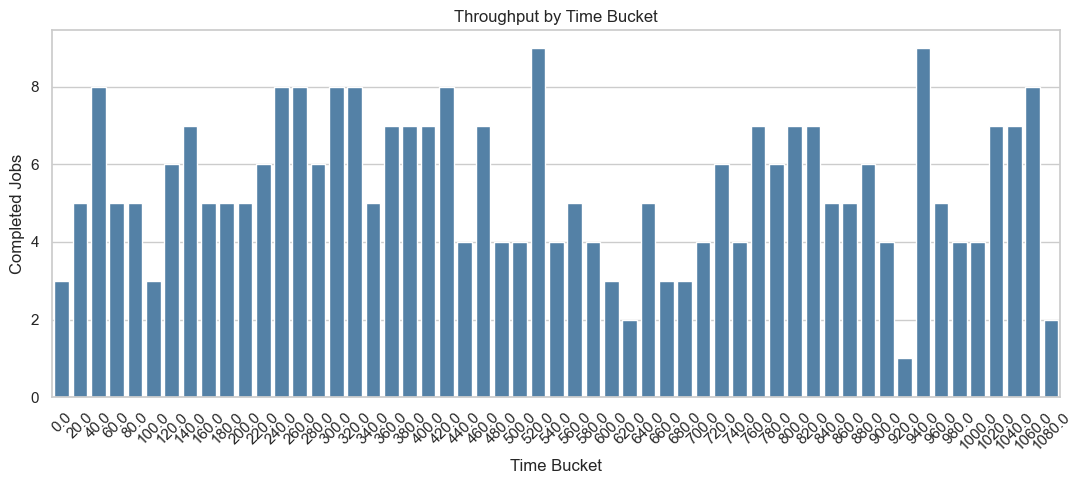

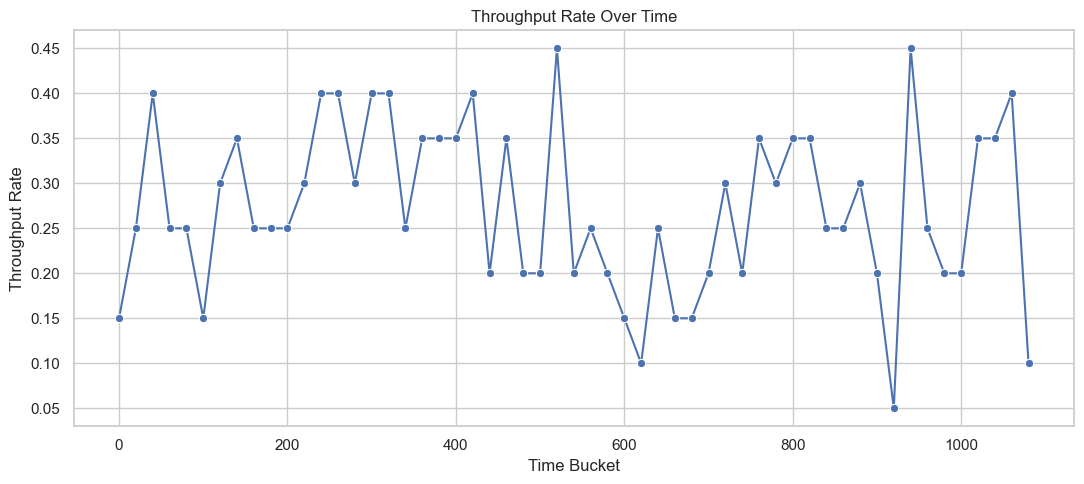

In [164]:
bucket_size = 20

sim_df["completion_bucket"] = (sim_df["completion_time"] // bucket_size) * bucket_size

throughput_by_bucket = sim_df.groupby("completion_bucket").agg(
    completed_jobs=("job_id", "count")
).reset_index()

throughput_by_bucket["throughput_rate"] = throughput_by_bucket["completed_jobs"] / bucket_size

display(throughput_by_bucket.head())

plt.figure(figsize=(11, 5))
sns.barplot(
    data=throughput_by_bucket,
    x="completion_bucket",
    y="completed_jobs",
    color="steelblue"
)
plt.title("Throughput by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Completed Jobs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=throughput_by_bucket,
    x="completion_bucket",
    y="throughput_rate",
    marker="o"
)
plt.title("Throughput Rate Over Time")
plt.xlabel("Time Bucket")
plt.ylabel("Throughput Rate")
plt.tight_layout()
plt.show()

# WIP 계산

In [165]:
time_grid = np.linspace(
    sim_df["arrival_time"].min(),
    sim_df["completion_time"].max(),
    200
)

wip_rows = []

for_time = []

for t in time_grid:
    wip = ((sim_df["arrival_time"] <= t) & (sim_df["completion_time"] > t)).sum()
    waiting = ((sim_df["arrival_time"] <= t) & (sim_df["start_time"] > t)).sum()
    processing = ((sim_df["start_time"] <= t) & (sim_df["completion_time"] > t)).sum()
    
    wip_rows.append({
        "time": t,
        "wip": wip,
        "waiting_jobs": waiting,
        "processing_jobs": processing,
    })

wip_df = pd.DataFrame(wip_rows)

display(wip_df.head())

,time,wip,waiting_jobs,processing_jobs
0,1.003109,1,0,1
1,6.451409,3,2,1
2,11.899709,4,3,1
3,17.348008,4,3,1
4,22.796308,5,4,1


# WIP 시각화

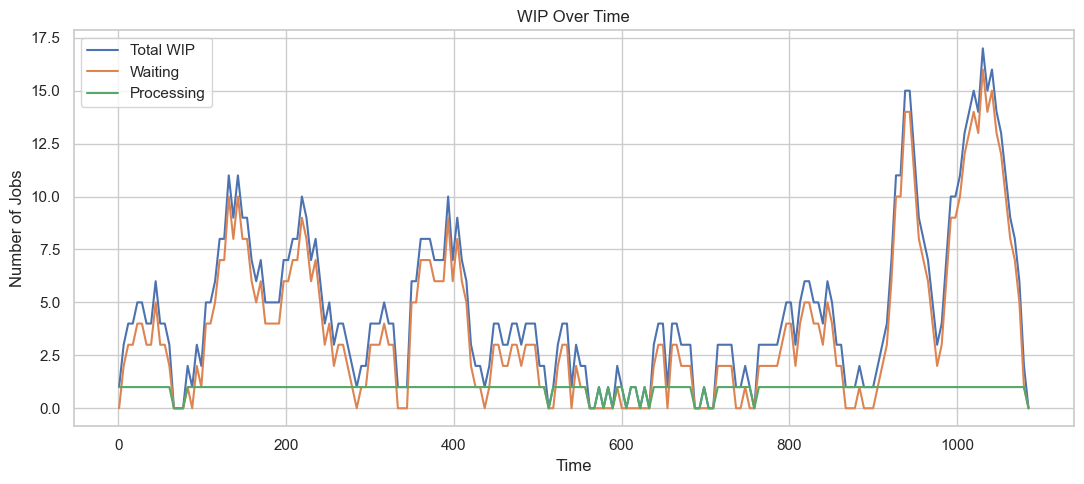

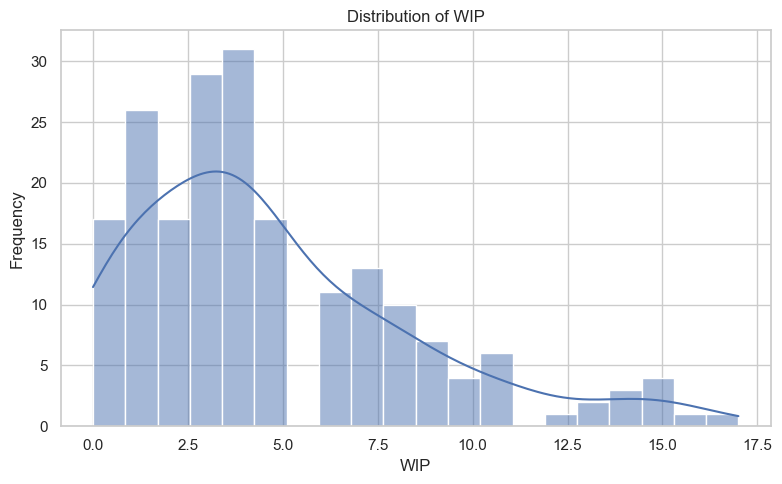

Average WIP: 4.675


In [166]:
plt.figure(figsize=(11, 5))
sns.lineplot(data=wip_df, x="time", y="wip", label="Total WIP")
sns.lineplot(data=wip_df, x="time", y="waiting_jobs", label="Waiting")
sns.lineplot(data=wip_df, x="time", y="processing_jobs", label="Processing")
plt.title("WIP Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Jobs")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(wip_df["wip"], bins=20, kde=True)
plt.title("Distribution of WIP")
plt.xlabel("WIP")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

avg_wip = wip_df["wip"].mean()
print("Average WIP:", avg_wip)

# Lead Time 분석

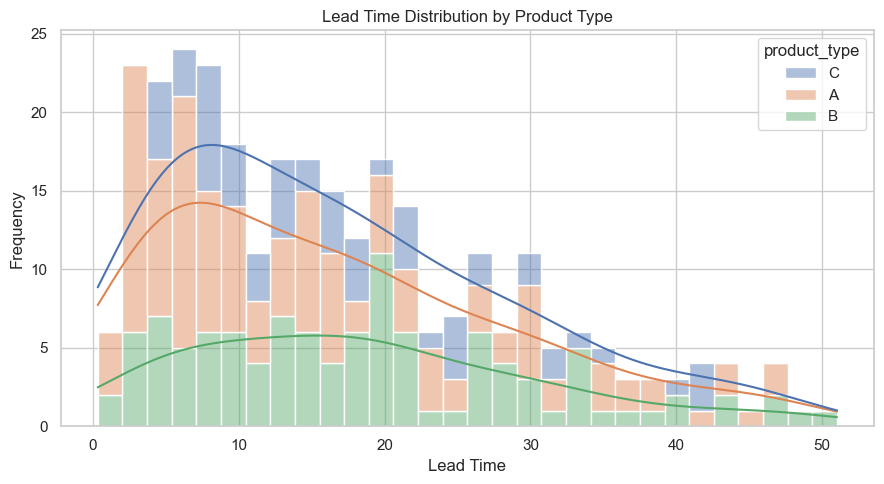

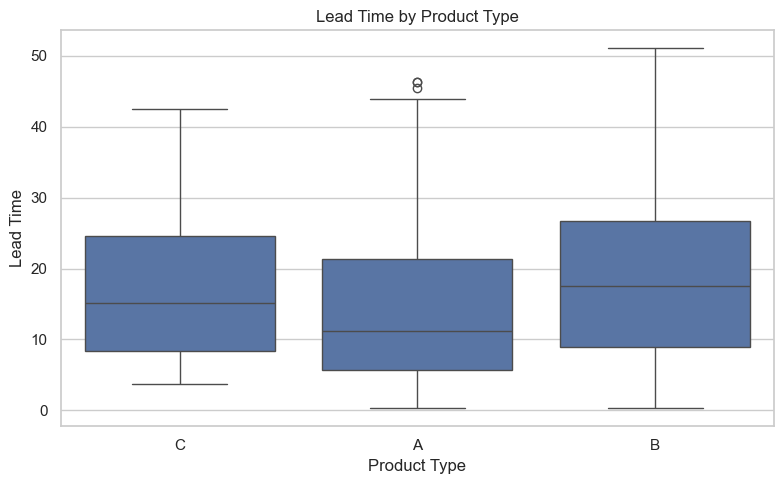

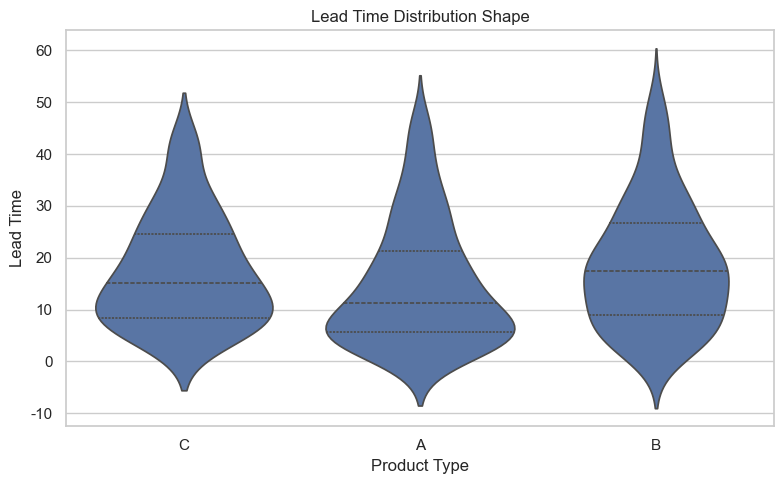

In [167]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=sim_df,
    x="lead_time",
    hue="product_type",
    bins=30,
    kde=True,
    multiple="stack",
    alpha=0.45
)
plt.title("Lead Time Distribution by Product Type")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=sim_df,
    x="product_type",
    y="lead_time"
)
plt.title("Lead Time by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Lead Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(
    data=sim_df,
    x="product_type",
    y="lead_time",
    inner="quartile"
)
plt.title("Lead Time Distribution Shape")
plt.xlabel("Product Type")
plt.ylabel("Lead Time")
plt.tight_layout()
plt.show()

# 납기 준수율 분석

,product_type,jobs,on_time_jobs,on_time_rate,avg_tardiness,max_tardiness
0,A,132,114,0.863636,0.936378,19.371459
1,B,108,91,0.842593,1.384633,22.948500
2,C,60,52,0.866667,0.958669,13.681199


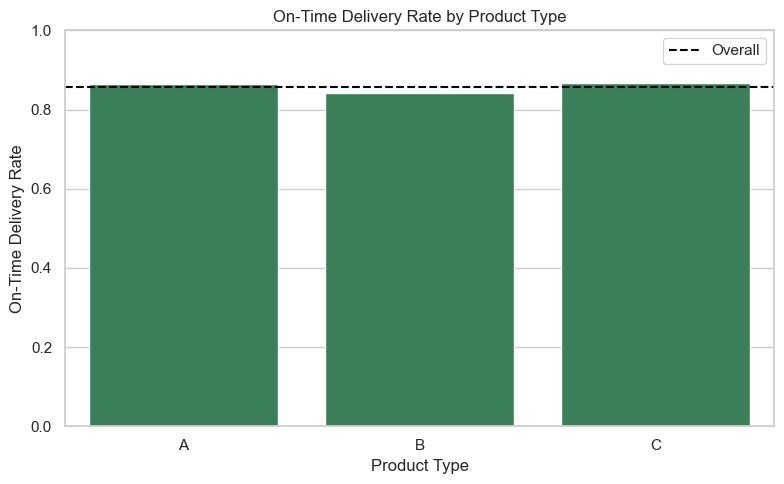

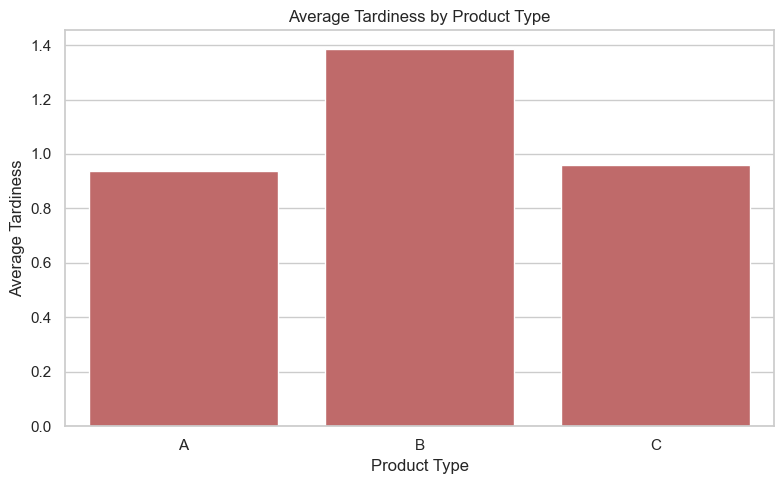

In [168]:
on_time_summary = sim_df.groupby("product_type").agg(
    jobs=("job_id", "count"),
    on_time_jobs=("on_time", "sum"),
    on_time_rate=("on_time", "mean"),
    avg_tardiness=("tardiness", "mean"),
    max_tardiness=("tardiness", "max"),
).reset_index()

display(on_time_summary)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=on_time_summary,
    x="product_type",
    y="on_time_rate",
    color="seagreen"
)
plt.axhline(sim_df["on_time"].mean(), color="black", linestyle="--", label="Overall")
plt.ylim(0, 1)
plt.title("On-Time Delivery Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("On-Time Delivery Rate")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=on_time_summary,
    x="product_type",
    y="avg_tardiness",
    color="indianred"
)
plt.title("Average Tardiness by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Average Tardiness")
plt.tight_layout()
plt.show()

# 납기 초과 작업만 따로 보기

,job_id,product_type,arrival_time,start_time,completion_time,processing_time,waiting_time,due_date,lead_time,flow_time,tardiness,lateness,on_time,completion_bucket
270,271,B,943.500672,991.490006,994.535379,3.045373,47.989334,971.586880,51.034708,51.034708,22.948500,22.948500,False,980.0
298,299,A,1038.716992,1079.473312,1082.366590,2.893278,40.756320,1062.995131,43.649598,43.649598,19.371459,19.371459,False,1080.0
269,270,B,943.255261,980.096835,991.490006,11.393171,36.841574,972.183093,48.234745,48.234745,19.306913,19.306913,False,980.0
296,297,B,1030.480029,1076.481406,1077.552189,1.070783,46.001377,1059.331108,47.072160,47.072160,18.221080,18.221080,False,1060.0
293,294,A,1028.129506,1071.219173,1072.065544,0.846370,43.089667,1054.620211,43.936038,43.936038,17.445333,17.445333,False,1060.0
297,298,B,1032.341146,1077.552189,1079.473312,1.921123,45.211042,1062.844011,47.132166,47.132166,16.629301,16.629301,False,1060.0
294,295,A,1029.280866,1072.065544,1074.774293,2.708749,42.784678,1060.587743,45.493427,45.493427,14.186550,14.186550,False,1060.0
290,291,C,1018.383608,1059.224836,1060.927982,1.703145,40.841228,1047.246783,42.544373,42.544373,13.681199,13.681199,False,1060.0
288,289,B,1013.956953,1056.292324,1057.952007,1.659683,42.335371,1044.690970,43.995054,43.995054,13.261037,13.261037,False,1040.0
289,290,C,1018.127951,1057.952007,1059.224836,1.272829,39.824057,1046.536249,41.096886,41.096886,12.688587,12.688587,False,1040.0


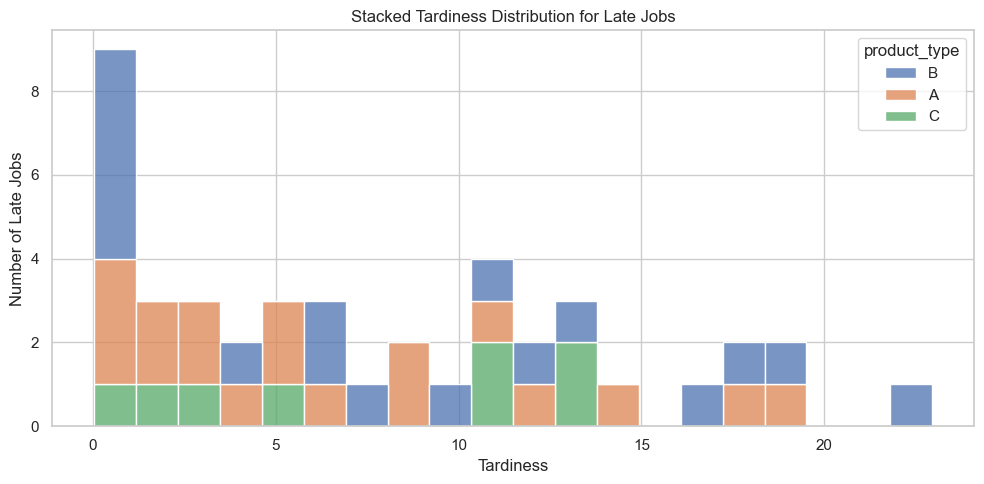

In [169]:
late_jobs = sim_df[sim_df["on_time"] == False].copy()
late_jobs = late_jobs.sort_values("tardiness", ascending=False)

display(late_jobs.head(10))

plt.figure(figsize=(10, 5))

sns.histplot(
    data=late_jobs,
    x="tardiness",
    hue="product_type",
    bins=20,
    multiple="stack",
    edgecolor="white"
)

plt.title("Stacked Tardiness Distribution for Late Jobs")
plt.xlabel("Tardiness")
plt.ylabel("Number of Late Jobs")
plt.tight_layout()
plt.show()

# Little's Law 점검

In [170]:
average_wip = wip_df["wip"].mean()
average_lead_time = sim_df["lead_time"].mean()
throughput_rate = len(sim_df) / total_time

littles_law_summary = pd.Series({
    "average_wip_observed": average_wip,
    "throughput_rate": throughput_rate,
    "average_lead_time": average_lead_time,
    "throughput_x_lead_time": throughput_rate * average_lead_time,
    "difference": average_wip - throughput_rate * average_lead_time,
})

display(littles_law_summary.to_frame("value"))

,value
average_wip_observed,4.675000
throughput_rate,0.276699
average_lead_time,16.757942
throughput_x_lead_time,4.636901
difference,0.038099


# KPI Dashboard 스타일 요약 그래프

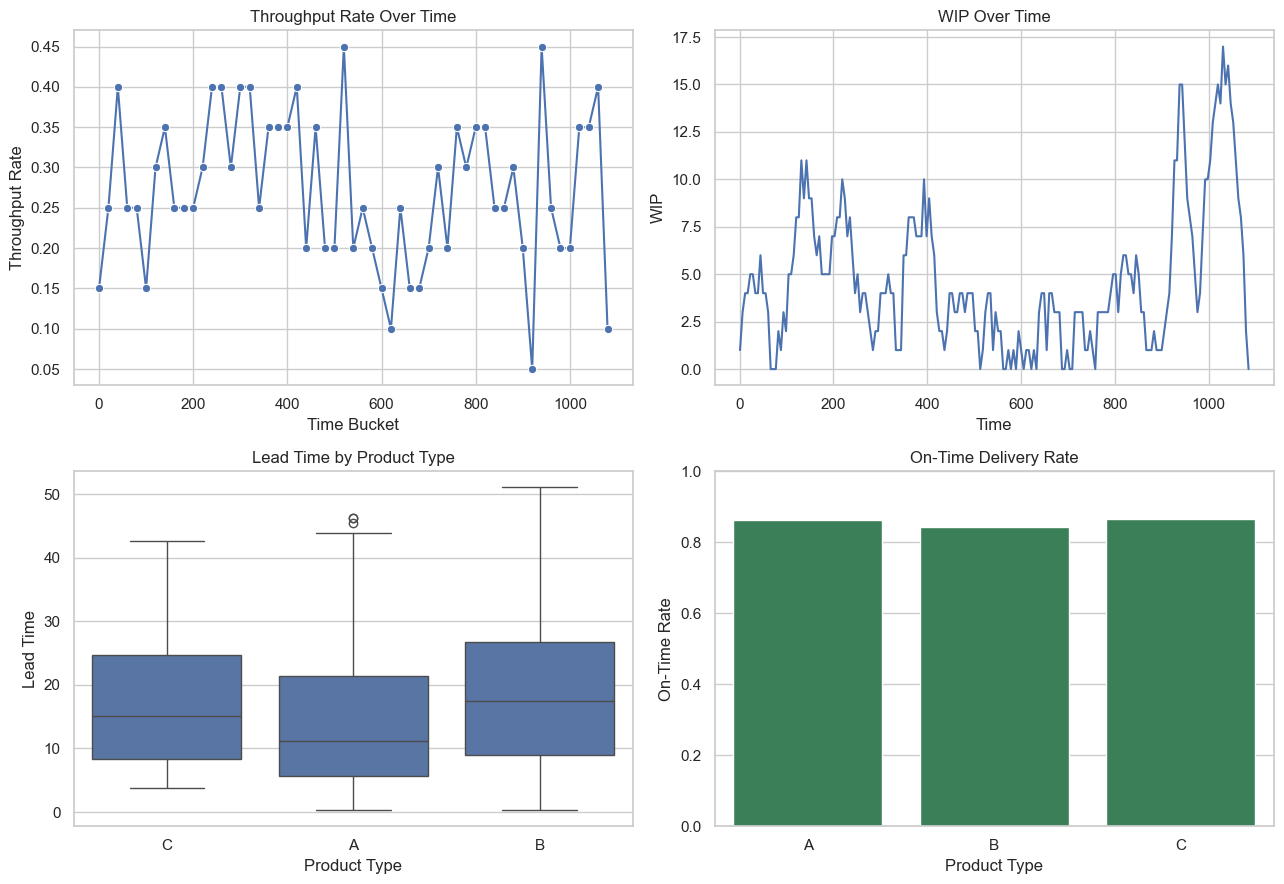

In [171]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.lineplot(
    data=throughput_by_bucket,
    x="completion_bucket",
    y="throughput_rate",
    marker="o",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Throughput Rate Over Time")
axes[0, 0].set_xlabel("Time Bucket")
axes[0, 0].set_ylabel("Throughput Rate")

sns.lineplot(
    data=wip_df,
    x="time",
    y="wip",
    ax=axes[0, 1]
)
axes[0, 1].set_title("WIP Over Time")
axes[0, 1].set_xlabel("Time")
axes[0, 1].set_ylabel("WIP")

sns.boxplot(
    data=sim_df,
    x="product_type",
    y="lead_time",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Lead Time by Product Type")
axes[1, 0].set_xlabel("Product Type")
axes[1, 0].set_ylabel("Lead Time")

sns.barplot(
    data=on_time_summary,
    x="product_type",
    y="on_time_rate",
    ax=axes[1, 1],
    color="seagreen"
)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].set_title("On-Time Delivery Rate")
axes[1, 1].set_xlabel("Product Type")
axes[1, 1].set_ylabel("On-Time Rate")

plt.tight_layout()
plt.show()

# 지표 간 관계 분석

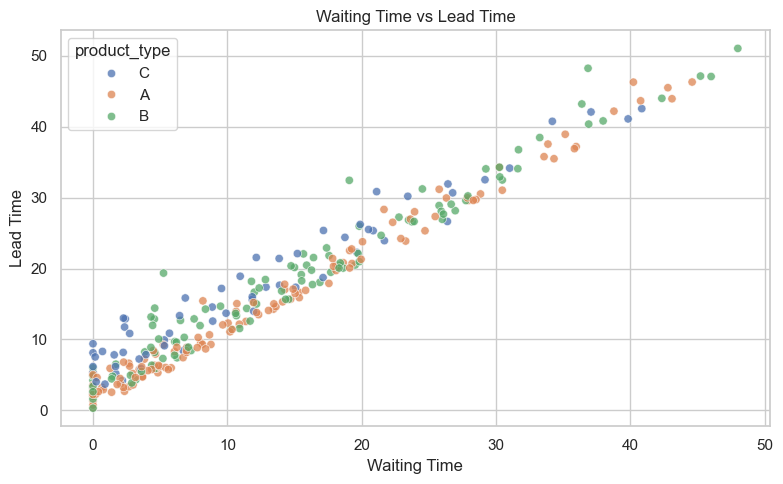

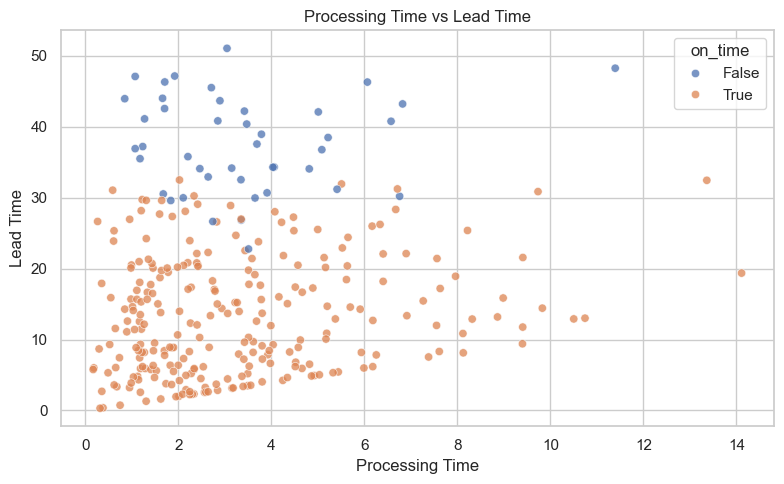

In [172]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sim_df,
    x="waiting_time",
    y="lead_time",
    hue="product_type",
    alpha=0.75
)
plt.title("Waiting Time vs Lead Time")
plt.xlabel("Waiting Time")
plt.ylabel("Lead Time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sim_df,
    x="processing_time",
    y="lead_time",
    hue="on_time",
    alpha=0.75
)
plt.title("Processing Time vs Lead Time")
plt.xlabel("Processing Time")
plt.ylabel("Lead Time")
plt.tight_layout()
plt.show()

# 결과 저장

In [173]:
# sim_df.to_csv("simulation_kpi_raw_data.csv", index=False)
# product_summary.to_csv("simulation_kpi_by_product.csv", index=False)
# throughput_by_bucket.to_csv("simulation_throughput_by_bucket.csv", index=False)
# wip_df.to_csv("simulation_wip_over_time.csv", index=False)
# on_time_summary.to_csv("simulation_on_time_summary.csv", index=False)

# print("CSV files saved.")

# 다중 replication

In [174]:
# 여러 replication 생성 + 전체 통계 + confidence interval plot

import simpy
from math import sqrt

try:
    from scipy.stats import t
    t_ppf = lambda q, df: t.ppf(q, df)
except Exception:
    # scipy가 없으면 replication 수가 충분히 크다는 가정으로 정규근사 사용
    t_ppf = lambda q, df: 1.96


def generate_simulation_replication(
    replication_id,
    n_jobs=300,
    seed=None,
    server_capacity=1,
    mean_interarrival=3.5,
    due_allowance_mean=30.0,
    due_allowance_std=2.5,
    min_due_allowance=10.0,
):
    """단순 SimPy 큐잉 모델로 replication 1회의 job-level 결과를 생성한다."""

    rng = np.random.default_rng(seed)

    job_id = np.arange(1, n_jobs + 1)

    # job 유형 생성
    product_type = rng.choice(
        ["A", "B", "C"],
        size=n_jobs,
        p=[0.45, 0.35, 0.20]
    )

    # 도착 과정: interarrival time을 지수분포로 생성한 뒤 누적하여 arrival time을 만든다.
    interarrival_time = rng.exponential(scale=mean_interarrival, size=n_jobs)
    arrival_time = np.cumsum(interarrival_time)

    # 제품군별 처리 시간 분포
    processing_time = np.where(
        product_type == "A",
        rng.gamma(shape=2.0, scale=1.2, size=n_jobs),
        np.where(
            product_type == "B",
            rng.gamma(shape=2.5, scale=1.5, size=n_jobs),
            rng.gamma(shape=3.0, scale=1.8, size=n_jobs),
        )
    )

    # 납기 생성
    due_allowance = rng.normal(loc=due_allowance_mean, scale=due_allowance_std, size=n_jobs)
    due_allowance = np.maximum(due_allowance, min_due_allowance)
    due_date = arrival_time + due_allowance

    records = []

    def job_process(env, server, idx):
        # 사전에 정해진 arrival_time까지 기다렸다가 시스템에 도착
        yield env.timeout(arrival_time[idx])
        arrived_at = env.now

        # 서버가 바쁘면 request 지점에서 queue에 대기
        with server.request() as request:
            yield request

            started_at = env.now
            waiting = started_at - arrived_at

            # processing time 동안 서버를 점유
            yield env.timeout(processing_time[idx])
            completed_at = env.now

        records.append({
            "replication": replication_id,
            "job_id": int(job_id[idx]),
            "product_type": product_type[idx],
            "arrival_time": arrived_at,
            "waiting_time": waiting,
            "start_time": started_at,
            "processing_time": processing_time[idx],
            "completion_time": completed_at,
            "due_date": due_date[idx],
        })

    # SimPy 환경과 서버 자원 생성
    env = simpy.Environment()
    server = simpy.Resource(env, capacity=server_capacity)

    # 모든 job process 등록
    for idx in range(n_jobs):
        env.process(job_process(env, server, idx))

    # 해당 replication의 모든 job이 완료될 때까지 실행
    env.run()

    df = (
        pd.DataFrame(records)
        .sort_values("job_id")
        .reset_index(drop=True)
    )

    # 후속 KPI/시각화 셀에서 사용하는 파생 지표
    df["lead_time"] = df["completion_time"] - df["arrival_time"]
    df["flow_time"] = df["lead_time"]
    df["tardiness"] = np.maximum(0, df["completion_time"] - df["due_date"])
    df["lateness"] = df["completion_time"] - df["due_date"]
    df["on_time"] = df["completion_time"] <= df["due_date"]

    return df


def calculate_wip_for_replication(df, n_grid=200):
    time_grid = np.linspace(
        df["arrival_time"].min(),
        df["completion_time"].max(),
        n_grid
    )

    rows = []

    for t_value in time_grid:
        rows.append({
            "replication": df["replication"].iloc[0],
            "time": t_value,
            "relative_time": (
                (t_value - df["arrival_time"].min())
                / (df["completion_time"].max() - df["arrival_time"].min())
            ),
            "wip": ((df["arrival_time"] <= t_value) & (df["completion_time"] > t_value)).sum(),
            "waiting_jobs": ((df["arrival_time"] <= t_value) & (df["start_time"] > t_value)).sum(),
            "processing_jobs": ((df["start_time"] <= t_value) & (df["completion_time"] > t_value)).sum(),
        })

    return pd.DataFrame(rows)


def calculate_replication_kpis(df, wip_df):
    total_time = df["completion_time"].max() - df["arrival_time"].min()

    return pd.Series({
        "number_of_jobs": len(df),
        "simulation_start": df["arrival_time"].min(),
        "simulation_end": df["completion_time"].max(),
        "total_time": total_time,
        "throughput_rate_jobs_per_time": len(df) / total_time,
        "average_wip": wip_df["wip"].mean(),
        "average_lead_time": df["lead_time"].mean(),
        "median_lead_time": df["lead_time"].median(),
        "average_waiting_time": df["waiting_time"].mean(),
        "average_processing_time": df["processing_time"].mean(),
        "on_time_delivery_rate": df["on_time"].mean(),
        "average_tardiness": df["tardiness"].mean(),
        "max_tardiness": df["tardiness"].max(),
    })


def confidence_interval_summary(data, metric_col, group_cols=None, confidence=0.95):
    if group_cols is None:
        group_cols = []

    rows = []
    grouped = data.groupby(group_cols, dropna=False) if group_cols else [((), data)]

    for group_key, group_df in grouped:
        values = group_df[metric_col].dropna()
        n = len(values)
        mean = values.mean()
        std = values.std(ddof=1)

        if n > 1:
            se = std / sqrt(n)
            t_value = t_ppf(1 - (1 - confidence) / 2, n - 1)
            half_width = t_value * se
        else:
            se = np.nan
            half_width = np.nan

        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = {
            "metric": metric_col,
            "n": n,
            "mean": mean,
            "std": std,
            "se": se,
            "ci_lower": mean - half_width,
            "ci_upper": mean + half_width,
            "ci_half_width": half_width,
        }

        for col, value in zip(group_cols, group_key):
            row[col] = value

        rows.append(row)

    return pd.DataFrame(rows)


In [175]:
# replication 실행

n_replications = 30
n_jobs_per_replication = 300
base_seed = 2025

all_sim_dfs = []
all_wip_dfs = []
replication_kpi_rows = []
product_kpi_rows = []

for r in range(1, n_replications + 1):
    rep_df = generate_simulation_replication(
        replication_id=r,
        n_jobs=n_jobs_per_replication,
        seed=base_seed + r
    )

    rep_wip_df = calculate_wip_for_replication(rep_df, n_grid=200)

    rep_kpis = calculate_replication_kpis(rep_df, rep_wip_df)
    rep_kpis["replication"] = r
    replication_kpi_rows.append(rep_kpis)

    product_rep_summary = rep_df.groupby("product_type").agg(
        jobs=("job_id", "count"),
        avg_lead_time=("lead_time", "mean"),
        median_lead_time=("lead_time", "median"),
        avg_waiting_time=("waiting_time", "mean"),
        avg_processing_time=("processing_time", "mean"),
        on_time_rate=("on_time", "mean"),
        avg_tardiness=("tardiness", "mean"),
        max_tardiness=("tardiness", "max"),
    ).reset_index()

    product_rep_summary["replication"] = r
    product_kpi_rows.append(product_rep_summary)

    all_sim_dfs.append(rep_df)
    all_wip_dfs.append(rep_wip_df)

multi_sim_df = pd.concat(all_sim_dfs, ignore_index=True)
multi_wip_df = pd.concat(all_wip_dfs, ignore_index=True)
replication_kpi_df = pd.DataFrame(replication_kpi_rows)
product_replication_kpi_df = pd.concat(product_kpi_rows, ignore_index=True)

display(replication_kpi_df.head())
display(product_replication_kpi_df.head())

,number_of_jobs,simulation_start,simulation_end,total_time,throughput_rate_jobs_per_time,average_wip,average_lead_time,median_lead_time,average_waiting_time,average_processing_time,on_time_delivery_rate,average_tardiness,max_tardiness,replication
0,300.0,5.330449,1138.714642,1133.384193,0.264694,4.295,16.045821,14.489321,12.634245,3.411576,0.886667,0.547917,11.541893,1.0
1,300.0,3.630135,1099.110997,1095.480862,0.273852,6.405,23.465364,24.139996,19.898388,3.566975,0.710000,2.337822,29.443034,2.0
2,300.0,3.126380,1053.643655,1050.517275,0.285574,4.400,15.445386,14.455057,12.140496,3.304890,0.920000,0.377439,14.351645,3.0
3,300.0,0.251197,1082.908804,1082.657607,0.277096,7.715,27.967381,22.421482,24.661647,3.305735,0.560000,8.337511,32.382064,4.0
4,300.0,5.960985,1100.666431,1094.705446,0.274046,5.770,21.317713,18.451710,17.986591,3.331122,0.690000,3.127919,22.704193,5.0


,product_type,jobs,avg_lead_time,median_lead_time,avg_waiting_time,avg_processing_time,on_time_rate,avg_tardiness,max_tardiness,replication
0,A,132,15.447208,14.215617,12.984062,2.463146,0.878788,0.611155,11.541893,1
1,B,115,16.510712,14.866193,12.899384,3.611328,0.886957,0.558027,10.761162,1
2,C,53,16.527983,14.961514,11.187703,5.340280,0.905660,0.368481,10.081069,1
3,A,133,22.167687,21.624936,19.665030,2.502656,0.721805,2.327886,28.738162,2
4,B,109,24.308529,25.431209,20.476946,3.831582,0.678899,2.038727,22.939435,2


In [176]:
# 전체 replication 기준 통계 요약

overall_metric_cols = [
    "throughput_rate_jobs_per_time",
    "average_wip",
    "average_lead_time",
    "median_lead_time",
    "average_waiting_time",
    "average_processing_time",
    "on_time_delivery_rate",
    "average_tardiness",
    "max_tardiness",
]

overall_ci_summary = pd.concat(
    [
        confidence_interval_summary(replication_kpi_df, metric)
        for metric in overall_metric_cols
    ],
    ignore_index=True
)

display(overall_ci_summary)

,metric,n,mean,std,se,ci_lower,ci_upper,ci_half_width
0,throughput_rate_jobs_per_time,30,0.273273,0.009891,0.001806,0.269580,0.276967,0.003693
1,average_wip,30,10.215167,4.838766,0.883434,8.408342,12.021991,1.806825
2,average_lead_time,30,37.678122,18.349708,3.350183,30.826228,44.530015,6.851894
3,median_lead_time,30,36.560523,20.487482,3.740485,28.910371,44.210674,7.650152
4,average_waiting_time,30,34.213392,18.242933,3.330689,27.401369,41.025415,6.812023
5,average_processing_time,30,3.464730,0.138815,0.025344,3.412895,3.516564,0.051834
6,on_time_delivery_rate,30,0.500111,0.232390,0.042428,0.413335,0.586887,0.086776
7,average_tardiness,30,15.736528,15.018196,2.741935,10.128642,21.344415,5.607886
8,max_tardiness,30,55.700694,30.337172,5.538784,44.372608,67.028780,11.328086


In [177]:
# 제품군별 replication 통계 요약

product_metric_cols = [
    "jobs",
    "avg_lead_time",
    "median_lead_time",
    "avg_waiting_time",
    "avg_processing_time",
    "on_time_rate",
    "avg_tardiness",
    "max_tardiness",
]

product_ci_summary = pd.concat(
    [
        confidence_interval_summary(
            product_replication_kpi_df,
            metric_col=metric,
            group_cols=["product_type"]
        )
        for metric in product_metric_cols
    ],
    ignore_index=True
)

display(product_ci_summary)

,metric,n,mean,std,se,ci_lower,ci_upper,ci_half_width,product_type
0,jobs,30,134.933333,9.209940,1.681497,131.494285,138.372381,3.439048,A
1,jobs,30,107.100000,9.628800,1.757970,103.504547,110.695453,3.595453,B
2,jobs,30,57.966667,8.864821,1.618488,54.656488,61.276845,3.310179,C
3,avg_lead_time,30,37.174965,19.331888,3.529504,29.956320,44.393611,7.218646,A
4,avg_lead_time,30,37.639539,17.332026,3.164380,31.167655,44.111424,6.471885,B
5,avg_lead_time,30,39.030272,18.399007,3.359184,32.159969,45.900574,6.870302,C
6,median_lead_time,30,36.397451,22.319172,4.074905,28.063336,44.731567,8.334116,A
7,median_lead_time,30,36.647218,19.281883,3.520374,29.447244,43.847192,7.199974,B
8,median_lead_time,30,38.225322,20.469230,3.737153,30.581986,45.868658,7.643336,C
9,avg_waiting_time,30,34.756676,19.268472,3.517926,27.561710,41.951641,7.194966,A


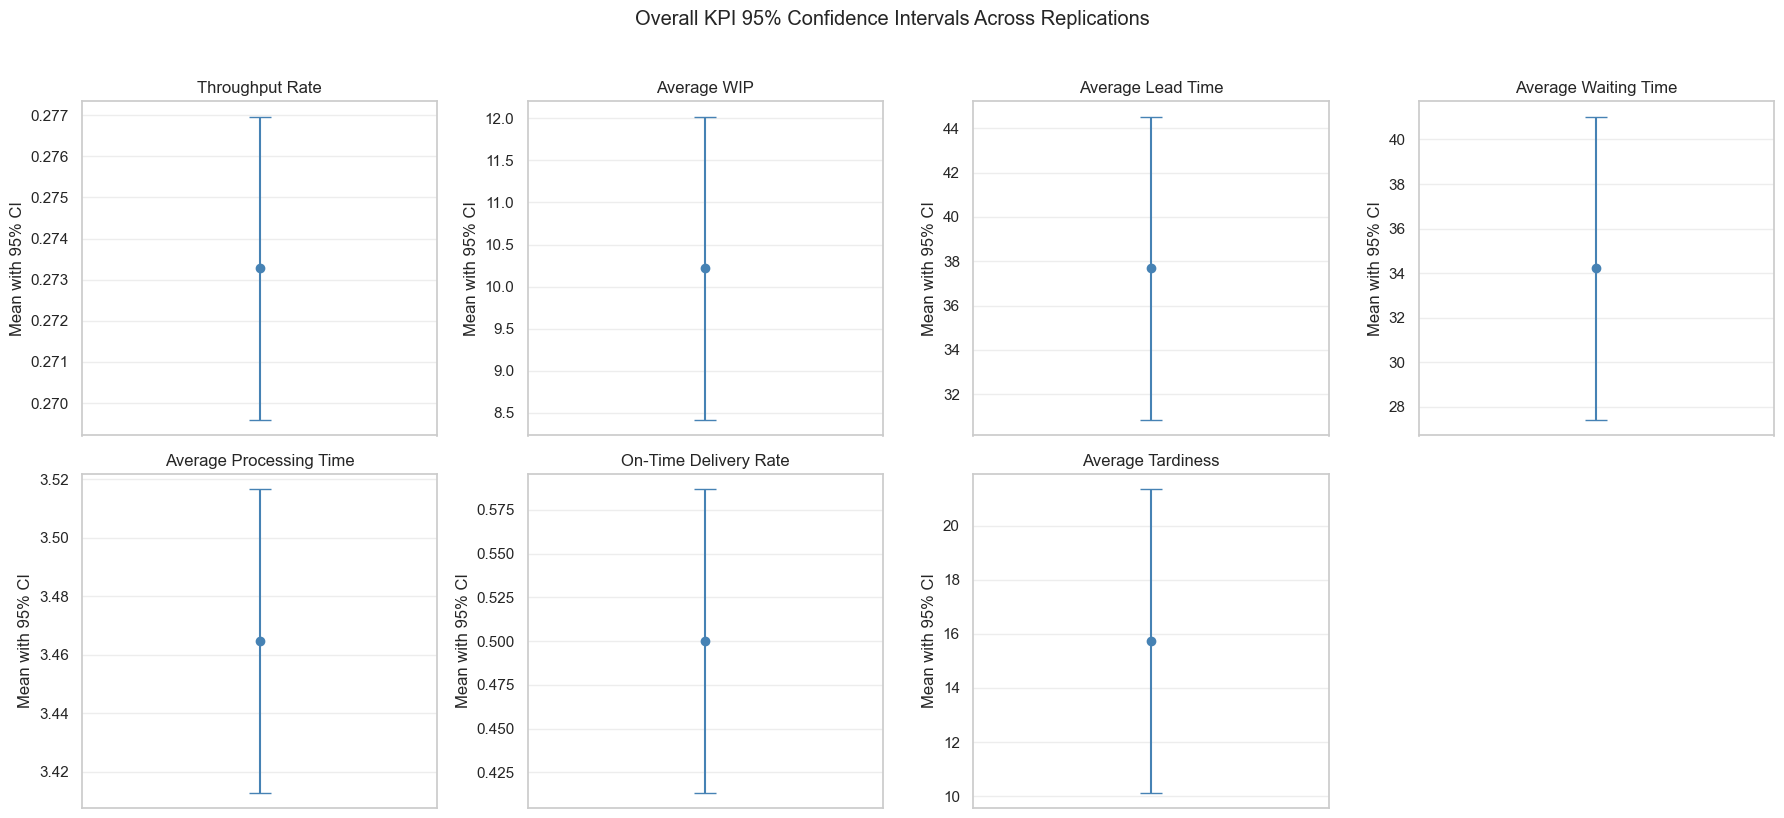

In [178]:
# 전체 KPI interval plot

plot_metrics = [
    "throughput_rate_jobs_per_time",
    "average_wip",
    "average_lead_time",
    "average_waiting_time",
    "average_processing_time",
    "on_time_delivery_rate",
    "average_tardiness",
]

plot_df = overall_ci_summary[
    overall_ci_summary["metric"].isin(plot_metrics)
].copy()

plot_df["metric_label"] = plot_df["metric"].replace({
    "throughput_rate_jobs_per_time": "Throughput Rate",
    "average_wip": "Average WIP",
    "average_lead_time": "Average Lead Time",
    "average_waiting_time": "Average Waiting Time",
    "average_processing_time": "Average Processing Time",
    "on_time_delivery_rate": "On-Time Delivery Rate",
    "average_tardiness": "Average Tardiness",
})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, plot_df.iterrows()):
    ax.errorbar(
        x=[0],
        y=[row["mean"]],
        yerr=[[row["mean"] - row["ci_lower"]], [row["ci_upper"] - row["mean"]]],
        fmt="o",
        capsize=8,
        color="steelblue"
    )
    ax.set_title(row["metric_label"])
    ax.set_xlim(-0.8, 0.8)
    ax.set_xticks([])
    ax.set_ylabel("Mean with 95% CI")
    ax.grid(True, axis="y", alpha=0.35)

for ax in axes[len(plot_df):]:
    ax.axis("off")

plt.suptitle("Overall KPI 95% Confidence Intervals Across Replications", y=1.02)
plt.tight_layout()
plt.show()

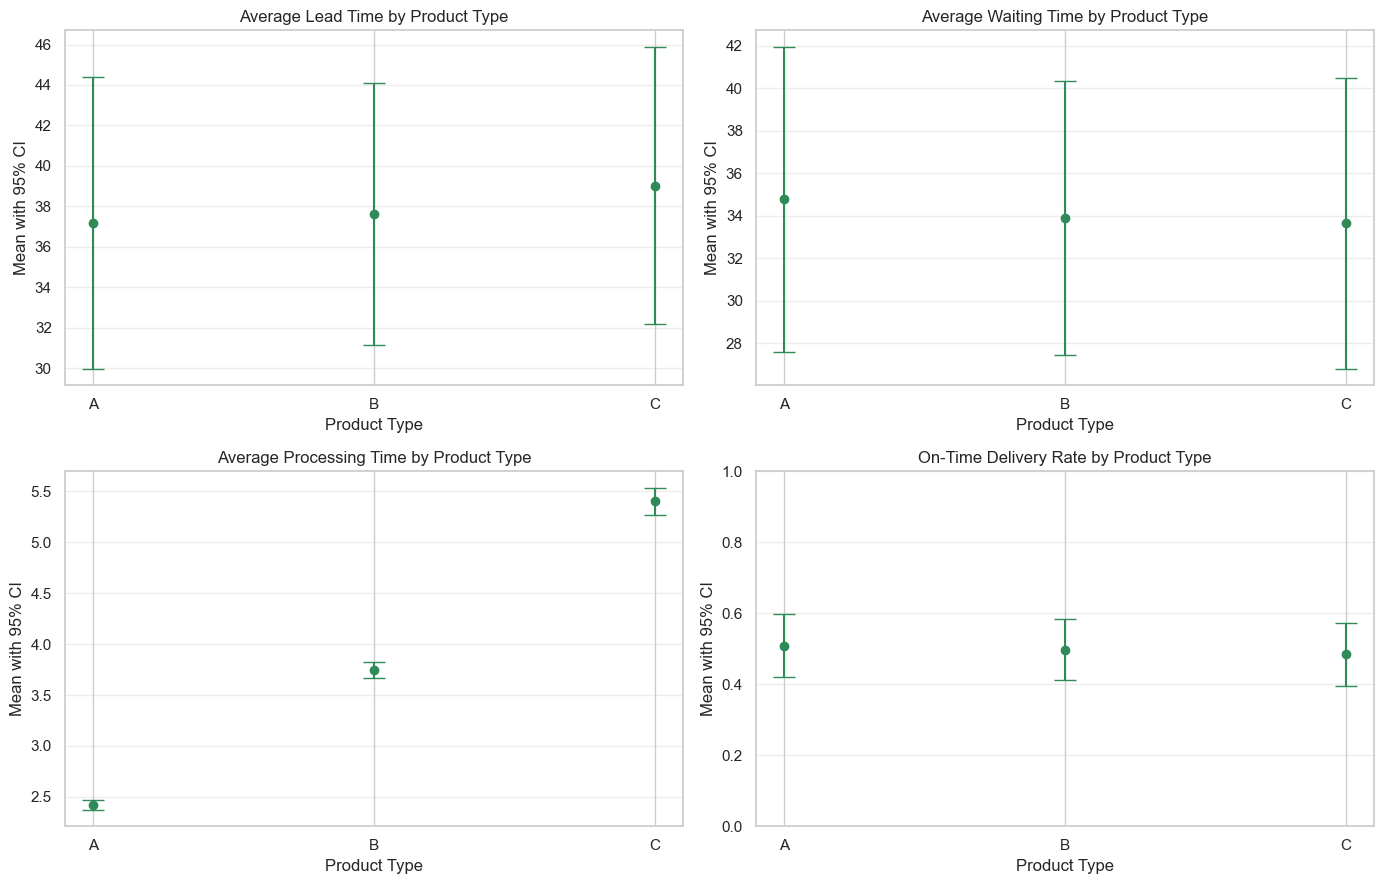

In [179]:
# 제품군별 interval plot: Lead Time, Waiting Time, Processing Time, On-Time Rate

product_plot_metrics = [
    "avg_lead_time",
    "avg_waiting_time",
    "avg_processing_time",
    "on_time_rate",
]

product_plot_titles = {
    "avg_lead_time": "Average Lead Time by Product Type",
    "avg_waiting_time": "Average Waiting Time by Product Type",
    "avg_processing_time": "Average Processing Time by Product Type",
    "on_time_rate": "On-Time Delivery Rate by Product Type",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, metric in zip(axes, product_plot_metrics):
    temp = product_ci_summary[
        product_ci_summary["metric"] == metric
    ].sort_values("product_type")

    x = np.arange(len(temp))

    ax.errorbar(
        x=x,
        y=temp["mean"],
        yerr=[
            temp["mean"] - temp["ci_lower"],
            temp["ci_upper"] - temp["mean"]
        ],
        fmt="o",
        capsize=8,
        color="seagreen"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(temp["product_type"])
    ax.set_title(product_plot_titles[metric])
    ax.set_xlabel("Product Type")
    ax.set_ylabel("Mean with 95% CI")
    ax.grid(True, axis="y", alpha=0.35)

    if metric == "on_time_rate":
        ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()